# Baseline Model

## Package Import & Path Settings

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import hashlib
from pathlib import Path
from collections import defaultdict
import time
from PIL import Image, UnidentifiedImageError

# pytorch
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from torchvision import transforms
from torch import nn
import torch

# data split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

# baseline models
from sklearn.dummy import DummyClassifier
from sklearn.metrics import log_loss

# others
from concurrent.futures import ThreadPoolExecutor
from src.dataset import load_filtered_imagefolder, rgba_to_rgb_with_bg, ds_test_split
from tqdm.auto import tqdm
from src.utils import plot_hist, plot_confusion_matrix_and_report, profile_dataloader, display_model_info
from src.training import load_checkpoint, get_last_checkpoint, get_last_checkpoint
from src.utils import profile_dataloader_grid_search, build_profile_heatmap_data

# path settings
from src import MODELS_DIR, PARAMS_PATH, SEED, PET_IMAGES_DIR, get_device
DEVICE = get_device()
print(f'Device: {DEVICE}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'PARAMS_PATH: {PARAMS_PATH}')
print(f'SEED: {SEED}')
print(f'PET_IMAGES_DIR: {PET_IMAGES_DIR}')

# project constants
label = {0:'cat', 1:'dog'}
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
SAMPLE_SIZE = 256


Device: cuda
MODELS_DIR: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\outputs\models
PARAMS_PATH: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\outputs\params
SEED: 37
PET_IMAGES_DIR: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\data\raw\PetImages


## Helper Functions

## Data Loading


In [3]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(SAMPLE_SIZE),    
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
val_tf = transforms.Compose([
    transforms.Resize(SAMPLE_SIZE),
    transforms.CenterCrop(SAMPLE_SIZE),    
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [4]:
bad_path = PET_IMAGES_DIR / 'bad_files.json'
dup_group_path = PET_IMAGES_DIR / 'duplicate_groups_exact.json'
ignore_path = PET_IMAGES_DIR / 'ignore_files_list.json'

ds_aug, excl_set = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, train_tf, rgba_to_rgb_with_bg) # the dataset with augmentation
ds, _ = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, val_tf, rgba_to_rgb_with_bg) # the dataset without any augmentation

print(f'Dataset Loaded from {PET_IMAGES_DIR}')
print(f'Number of valid samples: {len(ds)}')
print(f'Number of samples excluded: {len(excl_set)}')

Dataset Loaded from C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\data\raw\PetImages
Number of valid samples: 24968
Number of samples excluded: 32


### Test Data Split

Train / Test Data Split: 50%

In [5]:
idx_train, idx_test, y_train, y_test = ds_test_split(ds, 0.5, SEED, True)

## Baseline Model

A simple CNN model is constructed with PyTorch. The model consists of the following components:

**1) Feature extractor (backbone / conv stack)**
- **Conv2d** *(out_channels = 32 → 64 → 128 → 256, kernel=5, padding=2)*  
  Extract spatial features; padding keeps **H×W** unchanged **before pooling**.
- **BatchNorm2d** *(per channel)*  
  Normalizes activations using batch statistics during training; stabilizes and often speeds up convergence.
- **ReLU**  
  Adds non-linearity so the network can model complex decision boundaries.
- **MaxPool2d(2)**  
  Downsamples spatial resolution: **H, W → H/2, W/2** (done 4 times in this model).
- **AdaptiveAvgPool2d((1,1))** *(Global Average Pooling)*  
  Collapses each channel’s **H×W** feature map into **1×1**, producing a fixed-length representation.

**2) Classifier (head)**
- **Flatten**  
  Converts **(N, 256, 1, 1)** → **(N, 256)**.
- **Linear(256 → num_class)**  
  Outputs **logits** of shape **(N, num_class)** (e.g., **(N, 2)** for 2 classes).  
  *Logits are raw scores before softmax.*

---

**Shape Trace (Example)**
Assume input **x** has shape **(N, 3, H, W)**:

- After conv stack + pools: **(N, 256, H/16, W/16)**
- After AdaptiveAvgPool2d((1,1)): **(N, 256, 1, 1)**
- After flatten: **(N, 256)**
- After classifier: **(N, num_class)**

---

**Inference Helpers in This Class**
- `predict(x)`: returns **logits** (uses `no_grad()` + `eval()`).
- `predict_proba(x)`: returns **softmax probabilities** (uses `inference_mode()` + `eval()`).
- `predict_id(x)`: returns **argmax class indices** from probabilities.



In [6]:
class CNN_Clf(nn.Module):
    def __init__(self, num_class=2):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(3, 32, 5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(256, num_class)

        pass   

    def forward(self, x):
        x = self.feature(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits
    
    @ torch.no_grad()
    def predict(self, x):
        self.eval()
        return self.forward(x)
    
    @ torch.inference_mode()
    def predict_proba(self, x):
        self.eval()
        return torch.softmax(self.forward(x), dim=1, dtype=torch.float32)
    
    @ torch.inference_mode()
    def predict_id(self, x):
        self.eval()
        proba = self.predict_proba(x)
        ids = torch.argmax(proba, axis=1)       
        return ids


In [ ]:
model = CNN_Clf(2)
# Assuming 'model' is the CNN model instance
display_model_info(model)

Number of parameters: 1079554
Model size: 4.12 MB


Smoke test result shows no shape/data type error during the inferencing.

In [7]:
a = np.random.rand(32, 3, 128, 128).astype('float32')
a_tr = torch.from_numpy(a).to(DEVICE)
cnn_clf = CNN_Clf(2).to(DEVICE)
logits = cnn_clf.predict(a_tr).to('cpu').detach().numpy()
print(logits[0:5])


[[0.04315884 0.04294563]
 [0.04363328 0.04277388]
 [0.04285611 0.04308448]
 [0.04334048 0.04319836]
 [0.04288041 0.04315979]]


### Train Pipeline Throughput Optimization

Test different `DataLoader` parameters for optimal pipeline performance and training time.

In [ ]:
batch_size_list = [32, 64, 128, 256]
num_worker_list = [2, 4, 8]

from src.utils import profile_dataloader_grid_search, build_profile_heatmap_data

search_out = profile_dataloader_grid_search(
    ds=val_ds,
    model=model,
    device=device,
    param_grid={
        "batch_size": [32, 64, 128],
        "num_workers": [0, 2, 4, 8],
        "prefetch_factor": [2, 4],
    },
    mode="val",
    steps=100,
    warmup=20,
)

heat = build_profile_heatmap_data(
    search_out,
    x_param="num_workers",
    y_param="batch_size",
    metrics=["img_s", "gpu", "h2d", "load_ft"],  # load_ft alias -> load_tf
)


#### Training

#### Validation / Inference

In [ ]:

# --- Example usage ---
model = CNN_Clf(2).to(DEVICE)

# Train profiling
# out_tr = profile_dataloader(ds_aug, model, DEVICE, batch_size=32, num_workers=8, mode="train")
# print(out_tr)


In [ ]:

# Val profiling
out_va = profile_dataloader(ds, model, DEVICE, batch_size=64, num_workers=4, mode="val", drop_last=False)
print(out_va)


In [17]:
out_va = profile_dataloader(ds, model, DEVICE, batch_size=64, num_workers=4, mode="val", drop_last=False)
print(out_va)


{'mode': 'val', 'batch_size': 64, 'num_workers': 4, 'load_tf': 0.03766701949964044, 'h2d': 0.004925122499698773, 'gpu': 0.03772398402214051, 'total': 0.08088524599894299, 'img_s': 791.2444254770066, 'loader_kwargs': {'batch_size': 64, 'shuffle': False, 'num_workers': 4, 'pin_memory': True, 'persistent_workers': True, 'drop_last': False}}


In [19]:
display(profile_dataloader(ds, model, DEVICE, batch_size=128, num_workers=4, mode="val", drop_last=False))
display(profile_dataloader(ds, model, DEVICE, batch_size=128, num_workers=8, mode="val", drop_last=False))


{'mode': 'val',
 'batch_size': 128,
 'num_workers': 4,
 'load_tf': 0.0762374389996694,
 'h2d': 0.0094503970000369,
 'gpu': 0.07554072806119919,
 'total': 0.16222663599925,
 'img_s': 789.0196280750823,
 'loader_kwargs': {'batch_size': 128,
  'shuffle': False,
  'num_workers': 4,
  'pin_memory': True,
  'persistent_workers': True,
  'drop_last': False}}

{'mode': 'val',
 'batch_size': 128,
 'num_workers': 8,
 'load_tf': 0.007990764000423952,
 'h2d': 0.01275814850028837,
 'gpu': 0.10758221310079097,
 'total': 0.13091821250025532,
 'img_s': 977.7096521215517,
 'loader_kwargs': {'batch_size': 128,
  'shuffle': False,
  'num_workers': 8,
  'pin_memory': True,
  'persistent_workers': True,
  'drop_last': False}}

### Model Test

In [20]:
epochs = 100
batch_size = 32
val_batch_size = 128

hist = [{'loss':[], 'val_loss':[]}]

tr_idx, val_idx, y_tr, y_val = train_test_split(idx_train, y_train, test_size=0.2, random_state=SEED, shuffle=True, stratify=y_train)
ds_train = Subset(ds_aug, tr_idx)
ds_val = Subset(ds, val_idx)

tr_dl = DataLoader(ds_train, batch_size, shuffle=True, num_workers=8,          # try 2/4/8
    pin_memory=True,
    persistent_workers=True)
val_dl = DataLoader(ds_val, val_batch_size, shuffle=False, num_workers=8,          # try 2/4/8
    pin_memory=True,
    persistent_workers=True)

# cnn_clf = CNN_Clf(2).to(DEVICE)
# optim = torch.optim.Adam(cnn_clf.parameters(), lr=0.001) 
loss_fn = torch.nn.CrossEntropyLoss()

epoch_pbar = tqdm(range(epochs), desc='epoch', leave=False)
for e in epoch_pbar:
    epoch_pbar.set_description(f'epoch {e+1}/{epochs}')
    cnn_clf.train()
    fold_tr_size = 0
    fold_val_size = 0
    total_loss = 0 
    total_val_loss = 0
    for x, y in tqdm(tr_dl, desc=f"train e{e+1}", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optim.zero_grad(set_to_none=True)
        logits = cnn_clf(x)            
        loss = loss_fn(logits, y.long())
        bs = x.size(0)
        fold_tr_size += bs
        total_loss += loss.item() * bs
        train_loss = total_loss / fold_tr_size
        loss.backward()
        optim.step()
    hist[0]['loss'].append(train_loss)    
    # validation
    cnn_clf.eval()
    with torch.inference_mode():
        for x, y in tqdm(val_dl, desc=f"val e{e+1}", leave=False):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            logits = cnn_clf(x)
            loss = loss_fn(logits, y.long())
            bs = x.size(0)
            fold_val_size += bs
            total_val_loss += loss.item() * bs
            val_loss = total_val_loss / fold_val_size    
    hist[0]['val_loss'].append(val_loss)
    epoch_pbar.set_postfix(loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")
    if (e + 1) % 20 == 0:
        print(f'epoch: {e + 1}: train loss: {train_loss:.4f}, val_loss={val_loss:.4f}')

# dummy model
dummy_model = DummyClassifier(strategy='uniform')
dummy_model.fit(tr_idx, y_tr)
proba = dummy_model.predict_proba(tr_idx)
dummy_loss = log_loss(y_tr, proba, labels=[0,1])

epoch:   0%|          | 0/100 [00:00<?, ?it/s]

train e1:   0%|          | 0/313 [00:30<?, ?it/s]

val e1:   0%|          | 0/20 [00:27<?, ?it/s]

train e2:   0%|          | 0/313 [00:00<?, ?it/s]

val e2:   0%|          | 0/20 [00:00<?, ?it/s]

...

train e99:   0%|          | 0/313 [00:00<?, ?it/s]

val e99:   0%|          | 0/20 [00:00<?, ?it/s]

train e100:   0%|          | 0/313 [00:00<?, ?it/s]

val e100:   0%|          | 0/20 [00:00<?, ?it/s]

epoch: 100: train loss: 0.1157, val_loss=0.1363


In [31]:
timestr = time.strftime("%Y%m%d-%H-%M-%S")
torch.save(cnn_clf.state_dict(), MODELS_DIR / f'cnn_clf_{timestr}.pth')

In [22]:
with open(MODELS_DIR / 'hist_20260212-13-53-03.json', 'r') as f:
    hist_1 = json.load(f)

In [24]:
hist_1[0]['loss'].extend(hist[0]['loss'])
hist_1[0]['val_loss'].extend(hist[0]['val_loss'])


In [30]:
from src.config import PROJECT_ROOT
CKPT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"

ckpt_path = CKPT_DIR / f"ckpt_epoch_{e+1}.pt"
save_checkpoint(
    ckpt_path=ckpt_path,
    model=cnn_clf,
    optimizer=optim,
    epoch=e + 1,
    hist=hist,
    extra={
        "seed": SEED,
        "batch_size": batch_size,
        "val_batch_size": val_batch_size,
        "lr": 0.001,
    },
)

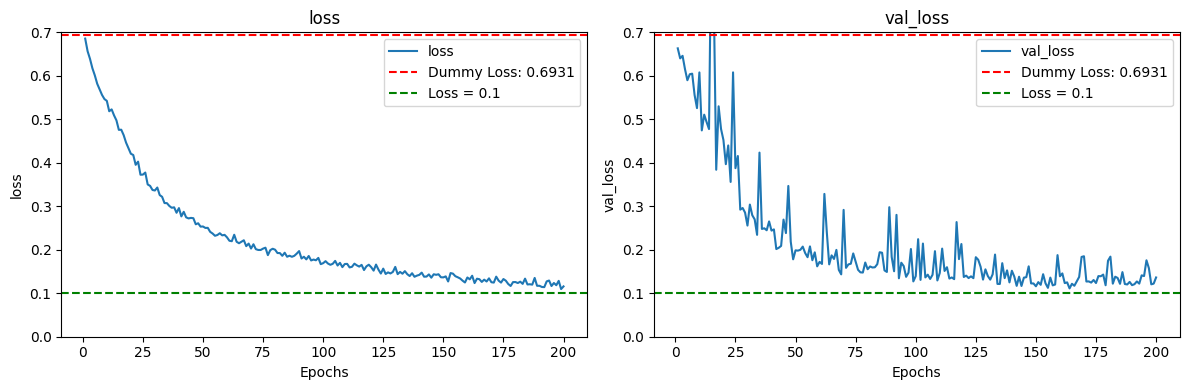

In [29]:
fig, ax = plot_hist(hist_1, show=False)
ax[0].axhline(y=dummy_loss, color='red', linestyle='--', label=f'Dummy Loss: {dummy_loss:.4f}')
ax[1].axhline(y=dummy_loss, color='red', linestyle='--', label=f'Dummy Loss: {dummy_loss:.4f}')
ax[0].axhline(y=0.1, color='green', linestyle='--', label=f'Loss = 0.1')
ax[1].axhline(y=0.1, color='green', linestyle='--', label=f'Loss = 0.1')
ax[0].set_ylim(0, 0.7)
ax[1].set_ylim(0, 0.7)
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
cnn_clf.eval()
y_pred = torch.tensor(np.empty_like([])).to(DEVICE)
y_val = torch.tensor(np.empty_like([])).to(DEVICE)
with torch.inference_mode():
    for x, y in tqdm(val_dl, desc=f"val e{e+1}", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        y_pred = torch.concat((y_pred, cnn_clf.predict_id(x)))
        y_val = torch.concat((y_val, y))

y_pred_np = y_pred.to('cpu').detach().numpy().astype('int')
y_val_np = y_val.to('cpu').detach().numpy().astype('int')
           
plot_confusion_matrix_and_report(y_val_np, y_pred_np, target_names=['cat', 'dog'])

val e100:   0%|          | 0/20 [00:00<?, ?it/s]

### Cross Validation

In [9]:
n_splits = 10
test_size = 0.1
skf = StratifiedShuffleSplit(n_splits=10, test_size=0.1, random_state=SEED)

In [ ]:
class CV_Trainer():
    def __init__(self, model, idx_train, y_train, cv, loss_fn, optim) -> None:
        self.model_cls, self.model_params = model
        self.idx_train = idx_train
        self.y_train = y_train
        self.spliter, self.split_groups = cv        
        self.loss_fn = loss_fn
        self.optimizer, self.optim_params = optim
        self.hist = []
        self.oof_y_pred = None
        
        pass
    def train(self, epochs, tr_bs, val_bs=None, tr_nw=4, val_nw=4):
        self.oof_y_pred = np.zeros_like(self.y_train)
        if self.split_groups is not None:
            fold_pbar = tqdm(self.spliter.split(self.idx_train, self.y_train, groups=self.split_groups), total=self.spliter.get_n_splits(), desc="CV folds")            
        else:
            fold_pbar = tqdm(self.spliter.split(self.idx_train, self.y_train), total=self.spliter.get_n_splits(), desc="CV folds")
        tr_bs = tr_bs
        if val_bs is None:
            val_bs = tr_bs

        for fold, (tr_idx, val_idx) in enumerate(fold_pbar):
            fold_hist = {'loss':[], 'val_loss':[]}
            fold_tr_dl = DataLoader(Subset(ds_aug, tr_idx), batch_size=tr_bs, num_workers=tr_nw)
            fold_val_dl = DataLoader(Subset(ds, val_idx), batch_size=val_bs, num_workers=val_nw)
            model = self.model_cls(**self.model_params)
            loss_fn = self.loss_fn()
            optim = self.optimizer(**self.optim_params)
            for e in range(epochs):    
                model.train()
                tr_bs = 0
                val_bs = 0
                total_loss = 0 
                total_val_loss = 0
                for x, y in tqdm(fold_tr_dl, desc=f"train e{e+1}", leave=False):
                    x = x.to(DEVICE, non_blocking=True)
                    y = y.to(DEVICE, non_blocking=True)
                    optim.zero_grad(set_to_none=True)
                    logits = model(x)            
                    loss = loss_fn(logits, y.long())
                    bs = x.size(0)
                    tr_bs += bs
                    total_loss += loss.item() * bs
                    train_loss = total_loss / tr_bs
                    loss.backward()
                    optim.step()
                fold_hist['loss'].append(train_loss)    
                # validation
                model.eval()
                with torch.inference_mode():
                    for x, y in tqdm(fold_val_dl, desc=f"val e{e+1}", leave=False):
                        x = x.to(DEVICE, non_blocking=True)
                        y = y.to(DEVICE, non_blocking=True)
                        logits = model(x)            
                        loss = loss_fn(logits, y.long())
                        bs = x.size(0)
                        val_bs += bs
                        total_val_loss += loss.item() * bs
                        val_loss = total_val_loss / val_bs
                fold_hist['val_loss'].append(val_loss)         
            hist.append(fold_hist)
            model.eval()            
            fold_y_pred = np.array([])
            with torch.inference_mode():
                for x, y in tqdm(fold_val_dl, desc=f"oof prediction", leave=False):
                    x = x.to(DEVICE, non_blocking=True)
                    y = y.to(DEVICE, non_blocking=True)
                    fold_y_pred = np.concat((fold_y_pred, model.predict_proba(x).to('cpu').detach().numpy()))
            self.oof_y_pred[val_idx] = fold_y_pred
        
        return 

## Baseline Model Performance

In [ ]:
ds_test = Subset(ds, idx_test)
dl_test = DataLoader(ds_test, batch_size=128, num_workers=8, shuffle=False, pin_memory=True, persistent_workers=True)

In [ ]:
cnn_clf.eval()
y_pred = torch.tensor(np.empty_like([])).to(DEVICE)
y_val = torch.tensor(np.empty_like([])).to(DEVICE)
with torch.inference_mode():
    for x, y in tqdm(dl_test, desc=f"val e{e+1}", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        y_pred = torch.concat((y_pred, cnn_clf.predict_id(x)))
        y_val = torch.concat((y_val, y))

y_pred_np = y_pred.to('cpu').detach().numpy().astype('int')
y_val_np = y_val.to('cpu').detach().numpy().astype('int')

           
plot_confusion_matrix_and_report(y_val_np, y_pred_np, target_names=['cat', 'dog'])